# Evaluación de Modelos y Validación Cruzada

**Universidad de los Andes — Minería de Datos**  
**Semana 3 — Evaluación de Modelos**

---

## Objetivos de aprendizaje

- Comprender el concepto de validación cruzada y su importancia en la evaluación de modelos.
- Implementar K-Fold Cross-Validation y analizar sus resultados.
- Comparar diferentes métodos de validación cruzada: K-Fold, Stratified K-Fold y LOOCV.
- Seleccionar el método de validación cruzada más apropiado según el contexto del problema.

## 1. Introducción a la Validación Cruzada

La validación cruzada es una técnica para evaluar la capacidad de generalización de un modelo estadístico, esencial para verificar la eficacia del modelo en nuevos datos. En este tutorial, utilizaremos la validación cruzada K-Fold para ilustrar cómo se entrena y evalúa un modelo en diferentes segmentos del conjunto de datos.

## 2. Configuración del Entorno

Primero, importamos las librerías necesarias y preparamos el conjunto de datos.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut

# Cargamos el conjunto de datos Iris
iris = load_iris()
X, y = iris.data, iris.target

## 3. K-Fold Cross-Validation

### 3.1 Implementación

Utilizaremos `KFold` de Scikit-Learn para dividir los datos en 5 folds. Mostraremos cómo se divide el conjunto de datos y cómo se entrena y evalúa el modelo en cada fold.

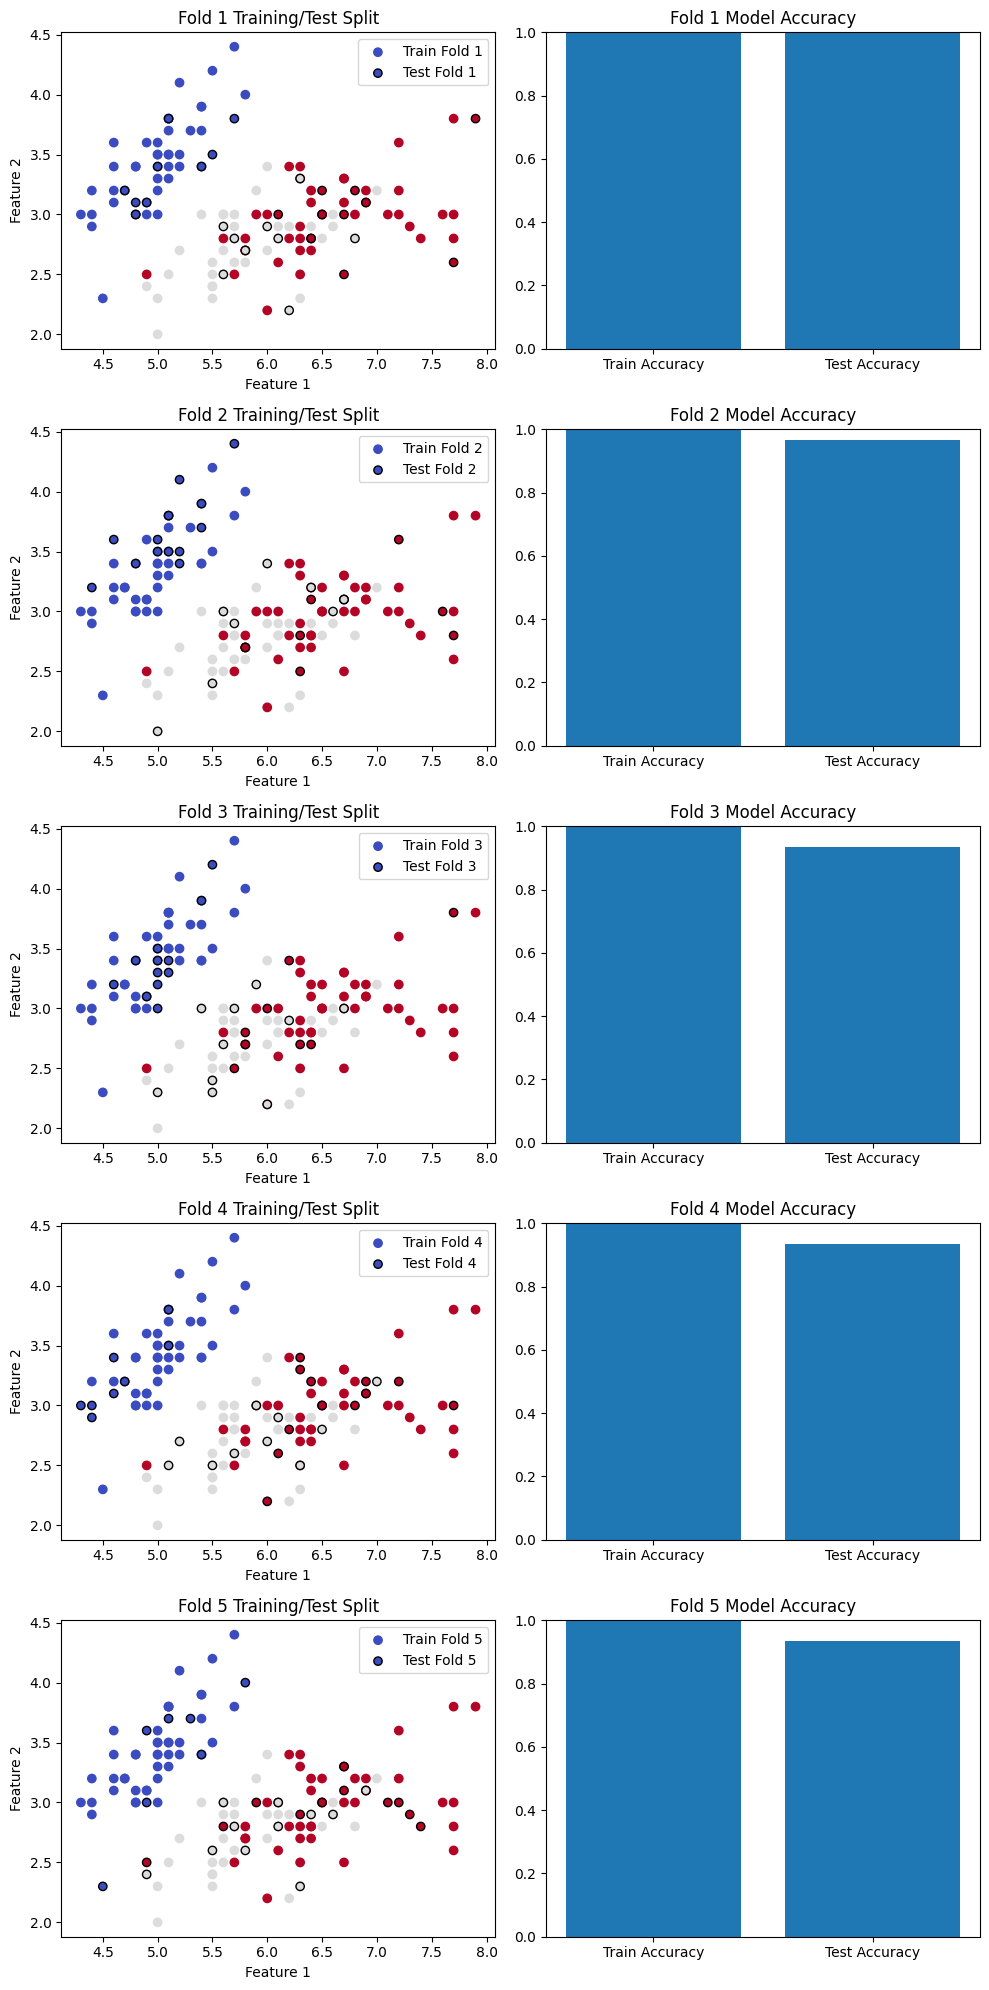

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))
fold = 0
for train_index, test_index in kf.split(X):
    # Seleccionamos los datos de entrenamiento y prueba para este fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Entrenamos el modelo
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Evaluamos el modelo
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    # Visualización de la división de entrenamiento/prueba
    axes[fold, 0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', label=f'Train Fold {fold+1}')
    axes[fold, 0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='black', label=f'Test Fold {fold+1}')
    axes[fold, 0].legend()
    axes[fold, 0].set_title(f'Fold {fold+1} Training/Test Split')
    axes[fold, 0].set_xlabel('Feature 1')
    axes[fold, 0].set_ylabel('Feature 2')

    # Visualización de la precisión
    axes[fold, 1].bar(['Train Accuracy', 'Test Accuracy'], [train_score, test_score])
    axes[fold, 1].set_title(f'Fold {fold+1} Model Accuracy')
    axes[fold, 1].set_ylim(0, 1)

    fold += 1

plt.tight_layout()
plt.show()


### 3.2 Análisis de Resultados

Después de entrenar y evaluar el modelo en cada fold, visualizamos cómo el modelo se ajusta a los diferentes segmentos del conjunto de datos y observamos las variaciones en la precisión del modelo.

Vamos a desarrollar distintos tipos de validación cruzada utilizando el conjunto de datos Iris. En este caso, compararemos los siguientes métodos:

1. **K-Fold Cross-Validation**
2. **Stratified K-Fold Cross-Validation**
3. **Leave-One-Out Cross-Validation (LOOCV)**

Para cada método, mostraremos las métricas de precisión obtenidas para cada iteración y las compararemos para entender las diferencias entre estos métodos de validación cruzada.

## 4. Comparación de Métodos

Primero, configuraremos nuestro entorno cargando las librerías necesarias y preparando el conjunto de datos.

Esto lo dejamos comentado porque ya esta realizado mas arriba. 

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cargamos el conjunto de datos Iris
iris = load_iris()
X, y = iris.data, iris.target

# Inicializamos el modelo
model = DecisionTreeClassifier(random_state=42)
```

A continuación, definimos una función que realizará la validación cruzada y recogerá las métricas de precisión para cada tipo.

In [6]:
from sklearn.metrics import accuracy_score

def perform_cross_validation(cv_method):
    scores = []
    for train_index, test_index in cv_method.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        scores.append(score)
    return scores

### 4.1 K-Fold Cross-Validation

Realizamos la validación cruzada usando K-Fold.

Primero, ejecutamos nuevamente K-Fold para comparación:

In [7]:
kf_scores = perform_cross_validation(KFold(n_splits=5, shuffle=True, random_state=42))
print("K-Fold Accuracy Scores:", kf_scores)

K-Fold Accuracy Scores: [1.0, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333]


### 4.2 Stratified K-Fold Cross-Validation

Ahora, realizamos la validación cruzada usando Stratified K-Fold para mantener la proporción de clases en cada fold.

In [10]:
skf_scores = perform_cross_validation(StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
print("Stratified K-Fold Accuracy Scores:", skf_scores)

Stratified K-Fold Accuracy Scores: [1.0, 0.9666666666666667, 0.9333333333333333, 0.9666666666666667, 0.9]


### 4.3 Leave-One-Out Cross-Validation (LOOCV)

Finalmente, probamos LOOCV, que es un caso extremo de K-Fold.

In [11]:
loo_scores = perform_cross_validation(LeaveOneOut())
print("LOOCV Accuracy Scores:", loo_scores)

LOOCV Accuracy Scores: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [15]:
len(loo_scores)


150

### 4.4 Comparación de Resultados

Vamos a visualizar y comparar las precisiones obtenidas con cada método.

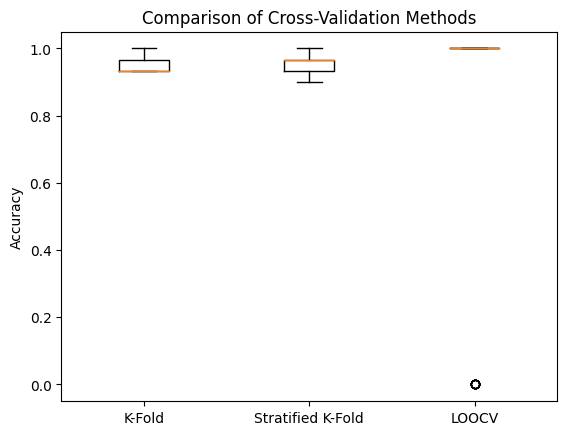

In [16]:
fig, ax = plt.subplots()
ax.boxplot([kf_scores, skf_scores, loo_scores], labels=['K-Fold', 'Stratified K-Fold', 'LOOCV'])
ax.set_title('Comparison of Cross-Validation Methods')
ax.set_ylabel('Accuracy')
plt.show()

## Referencias

**Texto guía**
- Notas de clase del curso (disponibles en el repositorio).

**Bibliografía complementaria**
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python* (Cap. 5). Springer.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (Cap. 7). Springer.
- Arlot, S., & Celisse, A. (2010). A survey of cross-validation procedures for model selection. *Statistics Surveys*, 4, 40–79.